# **Next generation datat science project**
## temperature predcition
##**student name : DANIEL**

##**dataset used** : Climate Insights Dataset

##**climate change regressions analysis :** develop a regression model to predict sea level rise

#**Import libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from zipfile import ZipFile

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Explainable AI
!pip install shap
import shap

#**Load dataset and structure**


In [ ]:
zip_path = "/content/sample_data/climate.zip"  # Your ZIP file path

with ZipFile(zip_path, 'r') as z:
    print("Files in ZIP:", z.namelist())  # Check files
    with z.open('climate_change_data.csv') as f:  # Pick the CSV
        df = pd.read_csv(f)

# Quick look
df.head()

Files in ZIP: ['Readme.md', 'climate_change_data.csv']


,Date,Location,Country,Temperature,CO2 Emissions,Sea Level Rise,Precipitation,Humidity,Wind Speed
0,2000-01-01 00:00:00.000000000,New Williamtown,Latvia,10.688986,403.118903,0.717506,13.835237,23.631256,18.492026
1,2000-01-01 20:09:43.258325832,North Rachel,South Africa,13.814430,396.663499,1.205715,40.974084,43.982946,34.249300
2,2000-01-02 16:19:26.516651665,West Williamland,French Guiana,27.323718,451.553155,-0.160783,42.697931,96.652600,34.124261
3,2000-01-03 12:29:09.774977497,South David,Vietnam,12.309581,422.404983,-0.475931,5.193341,47.467938,8.554563
4,2000-01-04 08:38:53.033303330,New Scottburgh,Moldova,13.210885,410.472999,1.135757,78.695280,61.789672,8.001164


##**basic data check**

In [ ]:
# Info & summary
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10000 non-null  object 
 1   Location        10000 non-null  object 
 2   Country         10000 non-null  object 
 3   Temperature     10000 non-null  float64
 4   CO2 Emissions   10000 non-null  float64
 5   Sea Level Rise  10000 non-null  float64
 6   Precipitation   10000 non-null  float64
 7   Humidity        10000 non-null  float64
 8   Wind Speed      10000 non-null  float64
dtypes: float64(6), object(3)
memory usage: 703.3+ KB
None
        Temperature  CO2 Emissions  Sea Level Rise  Precipitation  \
count  10000.000000   10000.000000    10000.000000   10000.000000   
mean      14.936034     400.220469       -0.003152      49.881208   
std        5.030616      49.696933        0.991349      28.862417   
min       -3.803589     182.131220       -4.092155       0.0101

##this dataset contains 10000 observations and 9 features which includes :

##* 6 numerical variables
##* 3 catagorical variables ( date, location, country

In [ ]:
# check how many unique countries and location
print("Unique countries:", df['Country'].nunique())
print("Unique locations:", df['Location'].nunique())

Unique countries: 243
Unique locations: 7764


#**Exploratory data analysis**

In [ ]:
# prepare the date and categorical columns
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract year and month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Quick look
df.head()

,Date,Location,Country,Temperature,CO2 Emissions,Sea Level Rise,Precipitation,Humidity,Wind Speed,Year,Month
0,2000-01-01 00:00:00.000000000,New Williamtown,Latvia,10.688986,403.118903,0.717506,13.835237,23.631256,18.492026,2000,1
1,2000-01-01 20:09:43.258325832,North Rachel,South Africa,13.814430,396.663499,1.205715,40.974084,43.982946,34.249300,2000,1
2,2000-01-02 16:19:26.516651665,West Williamland,French Guiana,27.323718,451.553155,-0.160783,42.697931,96.652600,34.124261,2000,1
3,2000-01-03 12:29:09.774977497,South David,Vietnam,12.309581,422.404983,-0.475931,5.193341,47.467938,8.554563,2000,1
4,2000-01-04 08:38:53.033303330,New Scottburgh,Moldova,13.210885,410.472999,1.135757,78.695280,61.789672,8.001164,2000,1


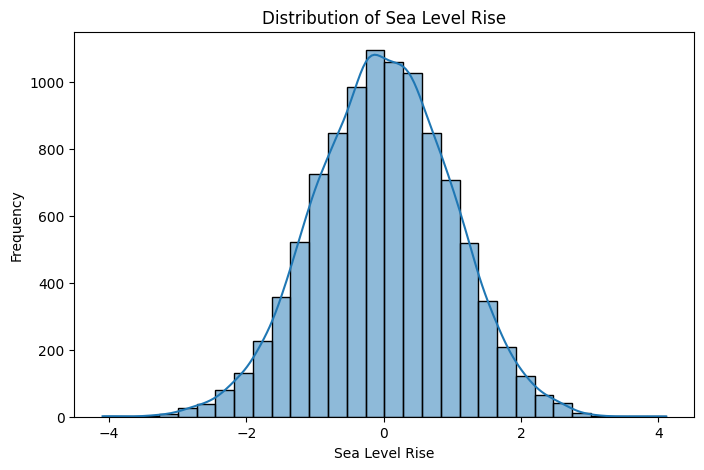

In [ ]:
# Sea Level Rise distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Sea Level Rise'], bins=30, kde=True)
plt.title("Distribution of Sea Level Rise")
plt.xlabel("Sea Level Rise")
plt.ylabel("Frequency")
plt.show()

##**observations**
##* The distribution is approximately symmetric and bell-shaped, centered around zero.

##* There are no extreme outliers or heavy tails

##* The overall shape resembles a normal distribution, suggesting moderate variability in sea level measurements.

##**implications for the model**

##* The symmetry and lack of skewness indicate that no transformation (e.g., log or Box-Cox) is needed for the target.

##* The narrow range and small variance may make it challenging for models to capture strong predictive relationships with the available features.


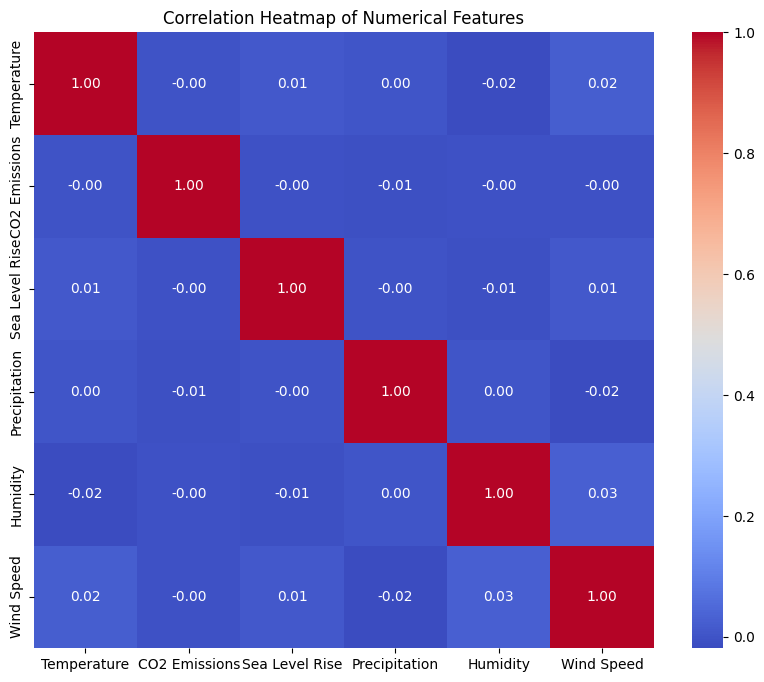

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,8))

numeric_cols = [
    'Temperature',
    'CO2 Emissions',
    'Sea Level Rise',
    'Precipitation',
    'Humidity',
    'Wind Speed'
]

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

##The figure above shows the heatmap which shows correlations between numerical variables
##* sea level rise shows very weak correlation with other environmental variables
##* no features indicates a strong positive or negative linear relationship

##This may affect the model as it may struggle to capture any meaningfull relationships and may result to a lower R²

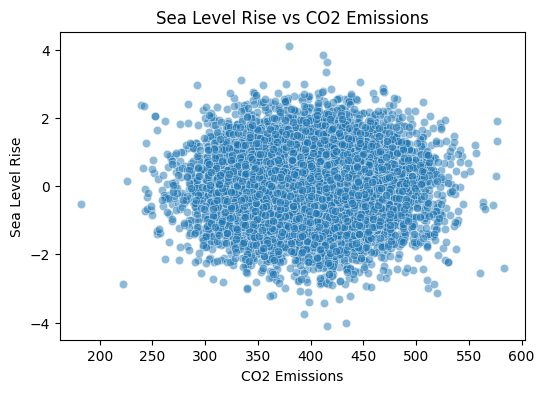

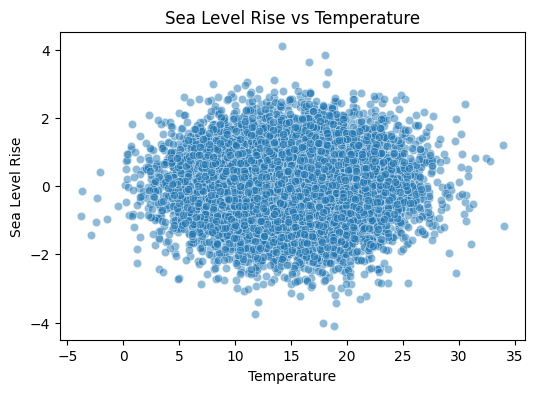

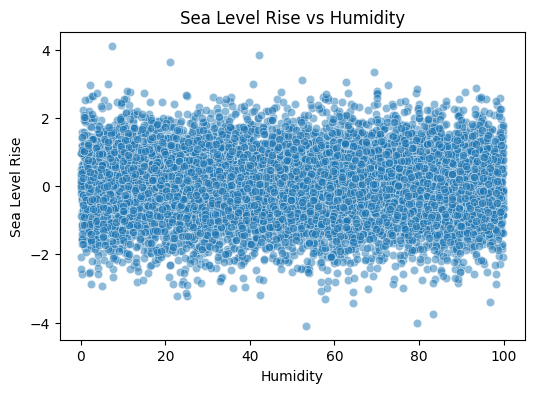

In [ ]:
# Sea Level Rise vs CO2 Emissions
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='CO2 Emissions', y='Sea Level Rise', alpha=0.5)
plt.title("Sea Level Rise vs CO2 Emissions")
plt.show()

# Sea Level Rise vs Temperature
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Temperature', y='Sea Level Rise', alpha=0.5)
plt.title("Sea Level Rise vs Temperature")
plt.show()

# Sea Level Rise vs Humidity
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Humidity', y='Sea Level Rise', alpha=0.5)
plt.title("Sea Level Rise vs Humidity")
plt.show()

##the box plots above shows the relationship between sea level rise and selected predictor variables
##* the data points shows no strong upward or downward pattern
##* relationships appear weak and noisy

##this suggests the following :    
##* limited predictive signals between sea level rise and these environmental variable
##* models may struggle due to the lack of structured relationships

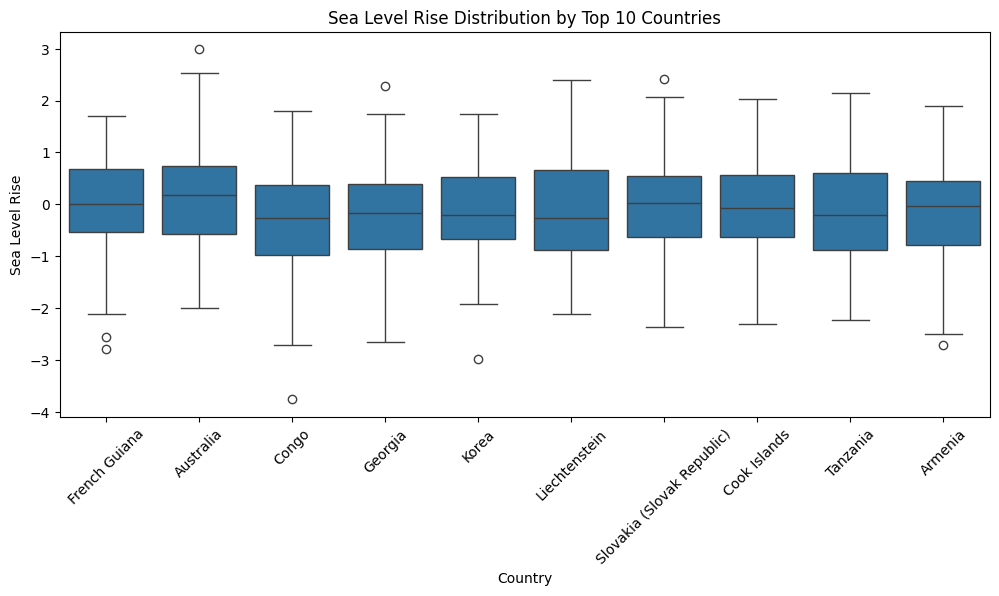

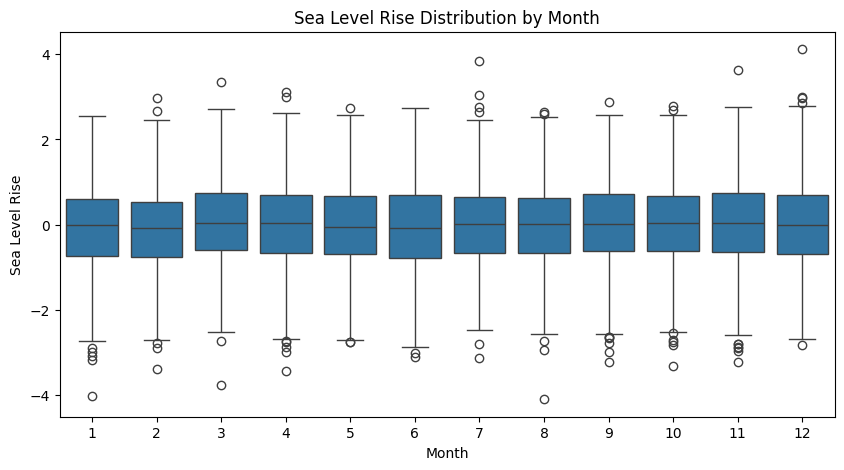

In [ ]:
# Sea Level Rise by Country (top 10 countries by frequency)
top_countries = df['Country'].value_counts().nlargest(10).index

plt.figure(figsize=(12,5))
sns.boxplot(
    data=df[df['Country'].isin(top_countries)],
    x='Country',
    y='Sea Level Rise'
)
plt.title("Sea Level Rise Distribution by Top 10 Countries")
plt.xticks(rotation=45)
plt.show()


# Sea Level Rise by Month
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x='Month',
    y='Sea Level Rise'
)
plt.title("Sea Level Rise Distribution by Month")
plt.show()

##**Sea Level Rise by Country**
##* Interquartile ranges are comparable which suggest consistent variability
##* Some outliers are visible in certain countries, but overall, the distributions do not show major differences.
##* this shows that the country leve features may not strongly influence sea level rise in the dataset

##**Sea Level Rise by Month**
##* shows no clear seasonal trend in sea level rise
##* median value close to zeroa across all months
##* this suggests limited temporal structure in the data for monthly prediction


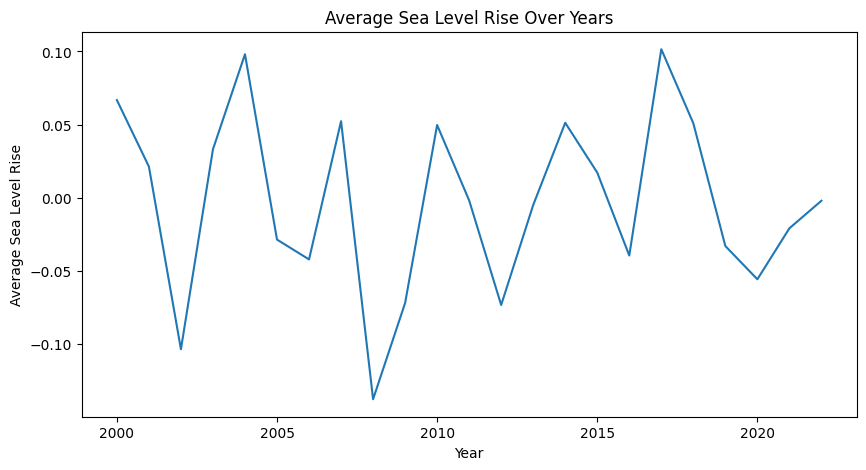

In [ ]:
plt.figure(figsize=(10,5))

yearly_sea_level = df.groupby('Year')['Sea Level Rise'].mean().reset_index()

sns.lineplot(data=yearly_sea_level, x='Year', y='Sea Level Rise')
plt.title("Average Sea Level Rise Over Years")
plt.xlabel("Year")
plt.ylabel("Average Sea Level Rise")
plt.show()

##the figure above does not show a strong upward or downward pattern.

##real-world climate data would typically show a upward trend overtime which may suggest that the dataset used does not reflect real world dynamic

#**preprocessing pipeline**


In [ ]:
# Drop ALL categorical-related columns
X = df.drop(columns=[
    'Sea Level Rise',
    'Date',
    'Country',
    'Location',
    'Country_reduced',
    'Location_reduced'
], errors='ignore')
y = df['Sea Level Rise']

# Re-check numeric features
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

print("Numeric features used:", numeric_features)

Numeric features used: ['Temperature', 'CO2 Emissions', 'Precipitation', 'Humidity', 'Wind Speed']


## Feature selections decisions

## dropped columns :    
##* date
##* country
##* locations
##* location

## locations and country resulted in many unique values which is very sparse after on-hot encoding

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
# build preprocessor
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

In [ ]:
# train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8000, 7)
Test shape: (2000, 7)


#**build models**

##**models chosen :**

##**linear regression**
##* simple and easily interpretable coefficients that quanitfy the linear relationship between each feature
##* baseline benchmark for other models

##**random forest regressor**
##* captures non linear relationships
##* robust to noise and outliers

##using these 2 models allows for :    
##* comparison on linear vs non linear approaches
##* Evaluate whether weak performance is due to model limitations or dataset limitations

##If both models perform poorly, this suggests limited predictive signal in the dataset rather than insufficient model complexity.

In [ ]:
# build linear regression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Create pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train model
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = lr_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

Linear Regression Performance
RMSE: 0.979652524491484
MAE: 0.7803910114545525
R² Score: -0.0008127219573514921


In [ ]:
# Get feature names
feature_names = numeric_features

# Extract coefficients
coefficients = lr_pipeline.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Feature,Coefficient
4,Wind Speed,0.015960
0,Temperature,0.007084
1,CO2 Emissions,-0.000395
2,Precipitation,-0.002578
3,Humidity,-0.007111


##train random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train model
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R² Score:", r2_rf)

Random Forest Performance
RMSE: 0.998653668642411
MAE: 0.7964469905322351
R² Score: -0.04001235095298106


In [ ]:
# Extract feature importances
rf_model = rf_pipeline.named_steps['regressor']
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': numeric_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
2,Precipitation,0.205000
1,CO2 Emissions,0.201669
4,Wind Speed,0.199425
3,Humidity,0.197860
0,Temperature,0.196046


##**model results**
##both models performed poorly with R² values close to zero which indicates almost no variance in target variable.

##this shows that the dataset has a weak predictive signal for Sea level rise

#**hyperparameter tuning for random forest**

##applied hyperparamter tuning to random forest regressor to further optimize its predictive performance for sea level rise

In [ ]:
# set up hyperparameter grid
from sklearn.model_selection import GridSearchCV

param_grid_small = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

In [ ]:
grid_search_small = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_small,
    cv=3,
    n_jobs=-1,
    scoring='r2',
    verbose=2
)

grid_search_small.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Temperature',
                                                                          'CO2 '
                                                                          'Emissions',
                                                                          'Precipitation',
                                                                          'Humidity',
                                                                          'Wind '
                                                                          'Speed'])])),
                                       ('regressor',
                                        RandomForestRegressor(n_estimators=200,
                                                              n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__max_depth': [None, 10],
                         'regressor__min_samples_leaf': [1, 2],
                         'regressor__min_samples_split': [2, 5],
                         'regressor__n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [ ]:
# best parameters
print("Best parameters found:", grid_search_small.best_params_)
print("Best CV R²:", grid_search_small.best_score_)

Best parameters found: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Best CV R²: -0.012011659276391176


In [ ]:
# evaluate tuned model on test set
y_pred_tuned = grid_search_small.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Performance")
print("RMSE:", rmse_tuned)
print("MAE:", mae_tuned)
print("R² Score:", r2_tuned)

Tuned Random Forest Performance
RMSE: 0.9814200597784515
MAE: 0.7827472187300109
R² Score: -0.004427406937214551


##although hyperparameter tuning improved the model over the default random forest, the R² still remains near zero.

##this further confirms that the dataset has a very weak predictive signal for sea level rise

###**AutoML** (FLAML)
##FLAML was selected because :    
##* it is lightweight and fast
##* supports regression task
##* transparent and flexible

In [ ]:
# install FLAML
!pip install flaml --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.7/337.7 kB 6.5 MB/s eta 0:00:00


In [ ]:
# import FLAML and prepare the date
from flaml import AutoML

# X_train, X_test, y_train, y_test already defined

In [ ]:
# initialize and fit AutoML
automl = AutoML()

# Specify settings
automl_settings = {
    "time_budget": 300,  # seconds, adjust for speed
    "metric": 'r2',      # optimize R²
    "task": 'regression',
    "log_file_name": "flaml_log.txt",
    "seed": 42
}

# Fit AutoML
automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

[flaml.automl.logger: 02-23 05:18:20] {2375} INFO - task = regression
[flaml.automl.logger: 02-23 05:18:20] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 02-23 05:18:20] {2489} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 02-23 05:18:20] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd']
[flaml.automl.logger: 02-23 05:18:20] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 02-23 05:18:20] {3046} INFO - Estimated sufficient time budget=1529s. Estimated necessary time budget=11s.
[flaml.automl.logger: 02-23 05:18:20] {3097} INFO -  at 0.2s,	estimator lgbm's best error=1.0012e+00,	best estimator lgbm's best error=1.0012e+00
[flaml.automl.logger: 02-23 05:18:20] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 02-23 05:18:21] {3097} INFO -  at 0.7s,	estimator lgbm's best error=1.0008e+00,	best estimator lgbm's best error=1.0008e+00
[flaml.automl.logger: 02-23 0

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 02-23 05:18:21] {3097} INFO -  at 0.8s,	estimator sgd's best error=1.0015e+00,	best estimator lgbm's best error=1.0008e+00
[flaml.automl.logger: 02-23 05:18:21] {2911} INFO - iteration 3, current learner sgd
[flaml.automl.logger: 02-23 05:18:21] {3097} INFO -  at 0.9s,	estimator sgd's best error=1.0008e+00,	best estimator lgbm's best error=1.0008e+00
[flaml.automl.logger: 02-23 05:18:21] {2911} INFO - iteration 4, current learner lgbm
[flaml.automl.logger: 02-23 05:18:22] {3097} INFO -  at 1.4s,	estimator lgbm's best error=1.0008e+00,	best estimator lgbm's best error=1.0008e+00
[flaml.automl.logger: 02-23 05:18:22] {2911} INFO - iteration 5, current learner sgd
[flaml.automl.logger: 02-23 05:18:22] {3097} INFO -  at 1.5s,	estimator sgd's best error=1.0008e+00,	best estimator lgbm's best error=1.0008e+00
[flaml.automl.logger: 02-23 05:18:22] {2911} INFO - iteration 6, current learner sgd
[flaml.automl.logger: 02-23 05:18:22] {3097} INFO -  at 1.5s,	estimator sgd's 

In [ ]:
# evaluate on test set
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred_automl = automl.predict(X_test)

rmse_automl = np.sqrt(mean_squared_error(y_test, y_pred_automl))
mae_automl = mean_absolute_error(y_test, y_pred_automl)
r2_automl = r2_score(y_test, y_pred_automl)

print("FLAML AutoML Performance")
print("RMSE:", rmse_automl)
print("MAE:", mae_automl)
print("R² Score:", r2_automl)

FLAML AutoML Performance
RMSE: 0.979300876875295
MAE: 0.7796759161943692
R² Score: -9.436471201929031e-05


| Metric   | Value    |
| -------- | -------- |
| RMSE     | 0.9793   |
| MAE      | 0.7797   |
| R² Score | -0.00009 |

##the R² Score being roughly close to 0 shows that the model does not explain the variance of the target variable

##this further confirms that the earlier observations from the random forest and linear regression model that the dataset has a very weak predictive signal for sea level rise

##despite the automatic model selection and hyperparameter tuning, performance remains

#**SHAP Explainable AI for Random Forest**

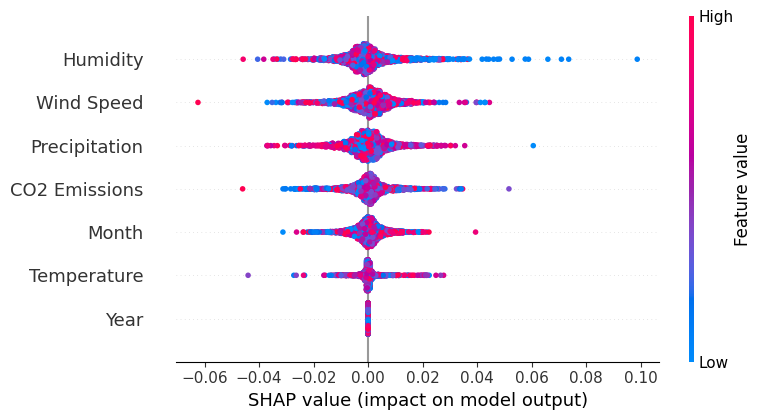

In [ ]:
import shap

# Use your Random Forest / FLAML model
model = automl.model.estimator  # or your RandomForestRegressor

# Make sure X_test is a DataFrame with correct column names
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

# Create TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)

# Summary plot (most important features)
shap.summary_plot(shap_values, X_test_df)

#**Key obeservation**
##* **Humidity** is the most impactful feature, with a wide spread of SHAP values. High humidity (red) tends to increase predictions, while low humidity (blue) tends to decrease them.

##* **Wind Speed, Precipitation, and CO₂ Emissions** also show significant influence, with high values generally increasing predictions and low values decreasing them.

##* **Month** has a moderate impact, with some high values (red) increasing predictions.

##* **Temperature** has a smaller impact, with high values (red) slightly increasing predictions.

##* **Year** has the least impact, with SHAP values tightly clustered around 0, indicating it contributes almost nothing to the model's output.